# WGAN-GP appliqué au FWI (Fire Weather Index) — 28×28

**Objectif :** entraîner un WGAN-GP léger pour générer des cartes journalières du FWI sur le sud-est de l'Espagne (28×28 pixels), à partir d'un dataset d'environ **10 000 jours**.

## Plan du notebook
1. Imports et paramètres
2. Chargement du parquet depuis MinIO + reconstruction du tenseur (N, 28, 28)
3. **Split temporel** :
   - **Train**  : 1970 → 2000
   - **Valid**  : 2001 → 2003
   - **Test**   : 2004 → 2005
4. Modèle WGAN-GP **naïf** (peu de couches, peu d'hyperparamètres — adapté à ~10 000 points)
5. Entraînement + suivi de la **loss train et valid** (loss Wasserstein du critic)
6. Comparaison **images générées vs vrais échantillons du test set**
7. **Fine-tuning** des hyperparamètres avec `keras-tuner` (Bayesian Optimization)

## Note méthodologique sur la "validation loss" d'un GAN
Un GAN n'a pas de loss supervisée classique : le générateur n'a pas de cible. On suit donc, comme proxy honnête :
- **`d_loss_train`** : loss Wasserstein + gradient penalty sur le train (= loss optimisée)
- **`w_loss_valid`** : `mean(D(fake)) - mean(D(real_valid))` calculée sur le **valid set**, **sans** gradient penalty et **sans** mise à jour des poids. Plus elle est proche de 0, moins le critic distingue vrai/faux sur des données jamais vues — donc mieux le générateur a appris la distribution.
- **`g_loss_valid`** : `-mean(D(fake))` évaluée avec le critic courant.



In [1]:
%pip install tensorflow keras-tuner s3fs --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Imports et paramètres

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ---- Hyperparamètres GAN naïf ------------------------------------------
# Volontairement modestes : ~10k échantillons => modèle léger pour éviter l'overfit.
latent_dim    = 64        
batch_size    = 64
epochs        = 30        
n_critic      = 3         # nb d'updates du discriminator par update du générateur
lambda_gp     = 10.0      # coefficient du gradient penalty
num_img       = 8         # nb d'images affichées
fit_verbosity = 1

# Constantes data
GRID_SIZE  = 28
VALUE_COL  = "fwi-daily-proj"

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {keras.__version__}")
print(f"GPU dispo  : {len(tf.config.list_physical_devices('GPU'))}")

I0000 00:00:1777149651.852695  659012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777149651.853524  659012 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777149651.943722  659012 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777149653.700765  659012 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

TensorFlow : 2.21.0
Keras      : 3.14.0
GPU dispo  : 0


E0000 00:00:1777149654.781304  659012 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## 2. Chargement du parquet et reconstruction du tenseur

In [ ]:
# =========================================================
# Rechargement du parquet depuis MinIO
# =========================================================
MY_BUCKET          = "matheo"
CHEMIN_FICHIER_OUT = "diffusion/data/fwi_se_spain_28x28.parquet"

fs = s3fs.S3FileSystem(client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"})
with fs.open(f"s3://{MY_BUCKET}/{CHEMIN_FICHIER_OUT}", "rb") as f:
    df_loaded = pd.read_parquet(f)

print(f"DataFrame chargé : {df_loaded.shape}")

# =========================================================
# Reconstruction du tenseur (N, 28, 28) 
# =========================================================
df_sorted = df_loaded.sort_values(["time", "lat", "lon"]).reset_index(drop=True)

# Vérification : chaque date a bien 784 pixels
counts = df_sorted.groupby("time").size()
assert (counts == GRID_SIZE * GRID_SIZE).all(), \
    f"Certaines dates n'ont pas {GRID_SIZE*GRID_SIZE} pixels"

n_dates = df_sorted["time"].nunique()
X       = df_sorted[VALUE_COL].values.reshape(n_dates, GRID_SIZE, GRID_SIZE)
dates   = np.sort(df_sorted["time"].unique())

# Coords lat/lon (constantes) — utiles pour l'affichage
df_one_date = df_sorted[df_sorted["time"] == df_sorted["time"].iloc[0]]
lats = np.sort(df_one_date["lat"].unique())
lons = np.sort(df_one_date["lon"].unique())

print(f"Tenseur X : {X.shape}")
print(f"min = {X.min():.3f}, max = {X.max():.3f}, mean = {X.mean():.3f}")

DataFrame chargé : (10308816, 4)
Tenseur X : (13149, 28, 28)
min = 0.000, max = 211.122, mean = 15.011


## 3. Split temporel : train / valid / test

| Split  | Années      | Usage                                              |
|--------|-------------|----------------------------------------------------|
| Train  | 1970 – 2000 | entraînement du GAN                                |
| Valid  | 2001 – 2003 | suivi de la loss Wasserstein hors-train            |
| Test   | 2004 – 2005 | comparaison qualitative générées vs réelles        |

On normalise par `x_max` calculé **uniquement sur le train** pour éviter toute fuite d'information.

In [4]:
dates_pd = pd.to_datetime(dates)
years    = dates_pd.year

train_mask = (years >= 1970) & (years <= 2000)
valid_mask = (years >= 2001) & (years <= 2003)
test_mask  = (years >= 2004) & (years <= 2005)

x_train = X[train_mask].astype("float32")
x_valid = X[valid_mask].astype("float32")
x_test  = X[test_mask ].astype("float32")

train_dates = dates_pd[train_mask]
valid_dates = dates_pd[valid_mask]
test_dates  = dates_pd[test_mask]

# ---- Normalisation [0, 1] basée sur le train uniquement ----------------
x_max  = x_train.max()
x_train = x_train / x_max
x_valid = x_valid / x_max
x_test  = x_test  / x_max

# ---- Ajout de la dim canal -> (N, 28, 28, 1) ---------------------------
x_train = x_train[..., np.newaxis]
x_valid = x_valid[..., np.newaxis]
x_test  = x_test[...,  np.newaxis]

# extent pour les imshow
extent = [lons.min(), lons.max(), lats.min(), lats.max()]

print(f"x_train : {x_train.shape}  ({years[train_mask].min()}-{years[train_mask].max()})")
print(f"x_valid : {x_valid.shape}  ({years[valid_mask].min()}-{years[valid_mask].max()})")
print(f"x_test  : {x_test.shape }  ({years[test_mask ].min()}-{years[test_mask ].max()})")
print(f"\nx_max (calculé sur train) = {x_max:.4f}")

x_train : (11323, 28, 28, 1)  (1970-2000)
x_valid : (1095, 28, 28, 1)  (2001-2003)
x_test  : (731, 28, 28, 1)  (2004-2005)

x_max (calculé sur train) = 185.9513


### Aperçu de quelques images du train

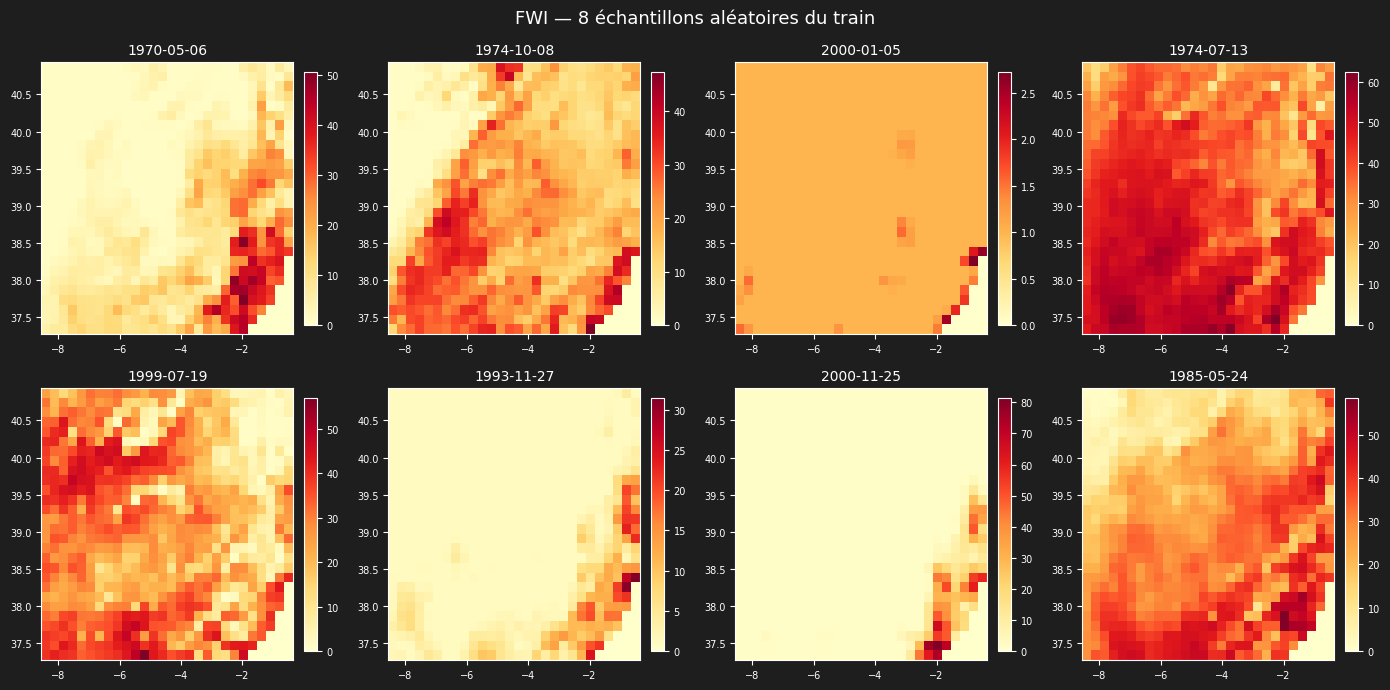

In [5]:
BG = "#1e1e1e"

fig, axes = plt.subplots(2, 4, figsize=(14, 7), facecolor=BG)
np.random.seed(0)
idx = np.random.choice(len(x_train), size=8, replace=False)

for k, i in enumerate(idx):
    ax = axes.ravel()[k]
    ax.set_facecolor(BG)
    img = x_train[i, ..., 0] * x_max
    im  = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    date_str = train_dates.iloc[i].strftime("%Y-%m-%d") if hasattr(train_dates, 'iloc') \
               else pd.Timestamp(train_dates[i]).strftime("%Y-%m-%d")
    ax.set_title(date_str, color="white", fontsize=10)
    ax.tick_params(colors="white", labelsize=7)
    for s in ax.spines.values(): s.set_color("white")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=7)
    cbar.outline.set_edgecolor("white")

plt.suptitle("FWI — 8 échantillons aléatoires du train", color="white", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Modèle WGAN-GP naïf

### 4.1 Critic / Discriminator (léger)
Le critic note un score scalaire (pas de sigmoid : c'est la distance de Wasserstein qui est apprise). On reste **léger** car :
- 10 000 points d'entraînement seulement,
- on veut éviter qu'il écrase trop le générateur.

In [ ]:
def build_discriminator():
    inputs = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(32, kernel_size=4, strides=2, padding="same")(inputs)   # 14x14
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(x)        #  7x7
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1)(x)   
    return keras.Model(inputs, out, name="critic")

discriminator = build_discriminator()
discriminator.summary()

/opt/python/lib/python3.13/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "critic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         3,137 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,513 (142.63 KB)

 Trainable params: 36,513 (142.63 KB)

 Non-trainable params: 0 (0.00 B)

### 4.2 Générateur (léger)
Architecture symétrique : un bruit latent → 7×7 → 14×14 → 28×28.

In [7]:
def build_generator(latent_dim):
    inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(7 * 7 * 64)(inputs)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Reshape((7, 7, 64))(x)

    x = layers.UpSampling2D()(x)                                              # 14x14
    x = layers.Conv2D(64, kernel_size=3, padding="same")(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    x = layers.UpSampling2D()(x)                                              # 28x28
    x = layers.Conv2D(32, kernel_size=3, padding="same")(x)
    x = layers.LeakyReLU(alpha=0.2)(x)

    out = layers.Conv2D(1, kernel_size=5, padding="same", activation="sigmoid")(x)
    return keras.Model(inputs, out, name="generator")

generator = build_generator(latent_dim)
generator.summary()

Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │       203,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           801 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,033 (1015.75 KB)

 Trainable params: 260,033 (1015.75 KB)

 Non-trainable params: 0 (0.00 B)

### 4.3 Classe `WGANGP` avec suivi de la loss validation

Version inspirée de `WGANGP.py` (Fidle), enrichie d'une **méthode `test_step`** qui calcule la loss Wasserstein du critic sur le valid set (sans gradient penalty, sans backprop). 

In [8]:
class WGANGP(keras.Model):
    # WGAN-GP avec validation step — suit la loss Wasserstein hors-train.

    def __init__(self, discriminator, generator, latent_dim=64,
                 n_critic=3, lambda_gp=10.0, **kwargs):
        super().__init__(**kwargs)
        self.discriminator = discriminator
        self.generator     = generator
        self.latent_dim    = latent_dim
        self.n_critic      = n_critic
        self.lambda_gp     = lambda_gp

    def call(self, inputs):
        return self.generator(inputs)

    def compile(self, d_optimizer, g_optimizer):
        super().compile()
        self.d_optimizer = d_optimizer
        self.g_optimizer = g_optimizer
        # métriques
        self.d_loss_metric = keras.metrics.Mean(name="d_loss")
        self.g_loss_metric = keras.metrics.Mean(name="g_loss")
        self.w_loss_metric = keras.metrics.Mean(name="w_loss")  # Wasserstein seule

    @property
    def metrics(self):
        return [self.d_loss_metric, self.g_loss_metric, self.w_loss_metric]

    # ----- Gradient penalty -------------------------------------------------
    def gradient_penalty(self, batch_size, real_images, fake_images):
        epsilon = tf.random.uniform([batch_size, 1, 1, 1], 0.0, 1.0)
        interpolated = epsilon * real_images + (1 - epsilon) * fake_images
        with tf.GradientTape() as gp_tape:
            gp_tape.watch(interpolated)
            interp_critics = self.discriminator(interpolated, training=True)
        grads = gp_tape.gradient(interp_critics, [interpolated])[0]
        norm  = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1, 2, 3]) + 1e-12)
        return self.lambda_gp * tf.reduce_mean((norm - 1.0) ** 2)

    # ----- Train step -------------------------------------------------------
    def train_step(self, inputs):
        if isinstance(inputs, tuple):
            real_images = inputs[0]
        else:
            real_images = inputs
        batch_size = tf.shape(real_images)[0]

        # --- n_critic updates du critic ---
        for _ in range(self.n_critic):
            z = tf.random.normal((batch_size, self.latent_dim))
            with tf.GradientTape() as tape:
                fake_images  = self.generator(z, training=True)
                fake_critics = self.discriminator(fake_images,  training=True)
                real_critics = self.discriminator(real_images,  training=True)
                w_loss = tf.reduce_mean(fake_critics) - tf.reduce_mean(real_critics)
                gp     = self.gradient_penalty(batch_size, real_images, fake_images)
                d_loss = w_loss + gp
            d_grads = tape.gradient(d_loss, self.discriminator.trainable_weights)
            self.d_optimizer.apply_gradients(zip(d_grads, self.discriminator.trainable_weights))

        # --- 1 update du générateur ---
        z = tf.random.normal((batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            fake_images  = self.generator(z, training=True)
            fake_critics = self.discriminator(fake_images, training=True)
            g_loss = -tf.reduce_mean(fake_critics)
        g_grads = tape.gradient(g_loss, self.generator.trainable_weights)
        self.g_optimizer.apply_gradients(zip(g_grads, self.generator.trainable_weights))

        # --- Update metrics ---
        self.d_loss_metric.update_state(d_loss)
        self.g_loss_metric.update_state(g_loss)
        self.w_loss_metric.update_state(w_loss)
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result(),
                "w_loss": self.w_loss_metric.result()}

    # ----- Validation step --------------------------------------------------
    def test_step(self, inputs):
        # Calcule la loss Wasserstein sur le valid (sans GP, sans backprop).
        if isinstance(inputs, tuple):
            real_images = inputs[0]
        else:
            real_images = inputs
        batch_size = tf.shape(real_images)[0]

        z            = tf.random.normal((batch_size, self.latent_dim))
        fake_images  = self.generator(z, training=False)
        fake_critics = self.discriminator(fake_images, training=False)
        real_critics = self.discriminator(real_images, training=False)

        w_loss = tf.reduce_mean(fake_critics) - tf.reduce_mean(real_critics)
        g_loss = -tf.reduce_mean(fake_critics)

        # On récupère val_w_loss / val_g_loss / val_d_loss dans l'history
        self.w_loss_metric.update_state(w_loss)
        self.g_loss_metric.update_state(g_loss)
        self.d_loss_metric.update_state(w_loss)   # pas de GP en valid
        return {"d_loss": self.d_loss_metric.result(),
                "g_loss": self.g_loss_metric.result(),
                "w_loss": self.w_loss_metric.result()}

### 4.4 Callback : sauvegarde d'images générées à chaque epoch
On fixe le bruit latent pour observer l'évolution des **mêmes** "personnages" au fil des epochs.

In [9]:
class FwiImagesCallback(keras.callbacks.Callback):

    def __init__(self, num_img=8, latent_dim=64, run_dir="./run_images", x_max=1.0,
                 extent=None, seed=0):
        super().__init__()
        self.num_img    = num_img
        self.latent_dim = latent_dim
        self.run_dir    = run_dir
        self.x_max      = x_max
        self.extent     = extent
        os.makedirs(run_dir, exist_ok=True)
        rng = np.random.default_rng(seed)
        self.fixed_z = rng.normal(size=(num_img, latent_dim)).astype("float32")

    def on_epoch_end(self, epoch, logs=None):
        gen = self.model.generator(self.fixed_z, training=False).numpy()
        fig, axes = plt.subplots(1, self.num_img, figsize=(2*self.num_img, 2.2),
                                 facecolor="#1e1e1e")
        for i, ax in enumerate(axes):
            ax.set_facecolor("#1e1e1e")
            img = gen[i, ..., 0] * self.x_max
            ax.imshow(img, cmap="YlOrRd", origin="lower",
                      extent=self.extent, aspect="auto")
            ax.set_xticks([]); ax.set_yticks([])
            for s in ax.spines.values(): s.set_color("white")
        plt.suptitle(f"Epoch {epoch+1:03d}", color="white", fontsize=11)
        plt.tight_layout()
        plt.savefig(f"{self.run_dir}/epoch_{epoch+1:03d}.png",
                    facecolor="#1e1e1e", dpi=80)
        plt.close(fig)

## 5. Entraînement du WGAN-GP naïf

In [10]:
# (re)build pour partir de poids frais
discriminator = build_discriminator()
generator     = build_generator(latent_dim)

gan = WGANGP(discriminator=discriminator,
             generator=generator,
             latent_dim=latent_dim,
             n_critic=n_critic,
             lambda_gp=lambda_gp)

gan.compile(
    d_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.9),
    g_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5, beta_2=0.9),
)

img_cb = FwiImagesCallback(
    num_img    = num_img,
    latent_dim = latent_dim,
    run_dir    = "./run_images_naive",
    x_max      = x_max,
    extent     = extent,
)

history = gan.fit(
    x_train,
    validation_data = x_valid,        # déclenche test_step à chaque epoch
    epochs          = epochs,
    batch_size      = batch_size,
    callbacks       = [img_cb],
    verbose         = fit_verbosity,
)

Epoch 1/30


E0000 00:00:1777149734.132375  659012 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/critic_9/leaky_re_lu_6_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/critic_9/conv2d_6_1/BiasAdd'.
E0000 00:00:1777149734.333329  659012 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


177/177 ━━━━━━━━━━━━━━━━━━━━ 25s 108ms/step - d_loss: -0.6795 - g_loss: -0.4917 - w_loss: -1.1261 - val_d_loss: -0.5956 - val_g_loss: -1.9978 - val_w_loss: -0.5956
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - d_loss: -0.5414 - g_loss: -0.4109 - w_loss: -0.5690 - val_d_loss: -0.7684 - val_g_loss: 2.4793 - val_w_loss: -0.7684
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 19s 107ms/step - d_loss: -0.4679 - g_loss: 1.5344 - w_loss: -0.5015 - val_d_loss: -0.6852 - val_g_loss: 2.9462 - val_w_loss: -0.6852
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 18s 101ms/step - d_loss: -0.3807 - g_loss: 1.7548 - w_loss: -0.4138 - val_d_loss: -0.3326 - val_g_loss: 1.6731 - val_w_loss: -0.3326
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 18s 104ms/step - d_loss: -0.3148 - g_loss: 2.6788 - w_loss: -0.3460 - val_d_loss: -0.2632 - val_g_loss: 1.6622 - val_w_loss: -0.2632
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step - d_loss: -0.2768 - g_loss: 3.0789 - w_loss: -0.3025 - val_d_loss: -0.2484 - val_g_loss: 

### 5.1 Loss train vs valid

- `w_loss` = `mean(D(fake)) - mean(D(real))` : **distance de Wasserstein estimée**. 
- `val_w_loss` = même chose sur le valid set, **sans** mise à jour des poids → indicateur de généralisation.


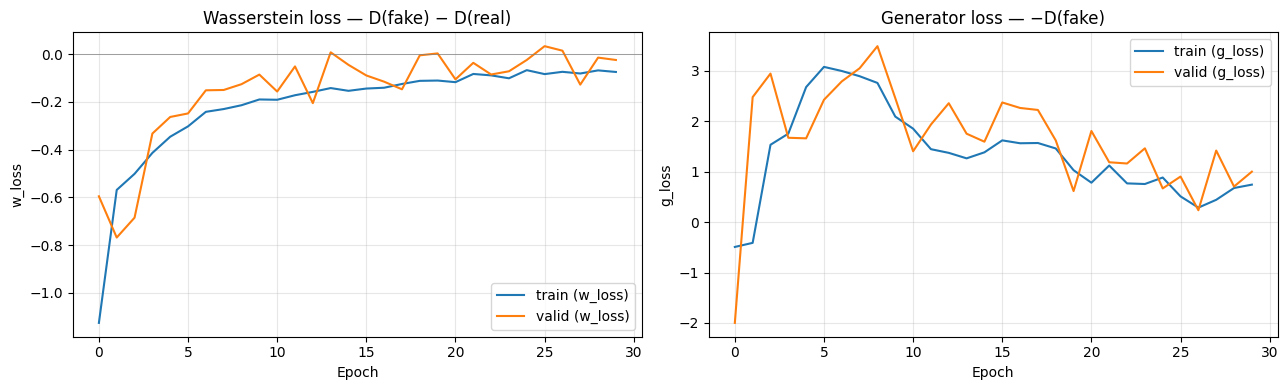

In [11]:
h = history.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(h["w_loss"],     label="train (w_loss)")
if "val_w_loss" in h:
    axes[0].plot(h["val_w_loss"], label="valid (w_loss)")
axes[0].set_title("Wasserstein loss — D(fake) − D(real)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("w_loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(0, color="grey", lw=0.5)

axes[1].plot(h["g_loss"],     label="train (g_loss)")
if "val_g_loss" in h:
    axes[1].plot(h["val_g_loss"], label="valid (g_loss)")
axes[1].set_title("Generator loss — −D(fake)")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("g_loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 Évolution des images générées (mêmes z fixés au fil des epochs)

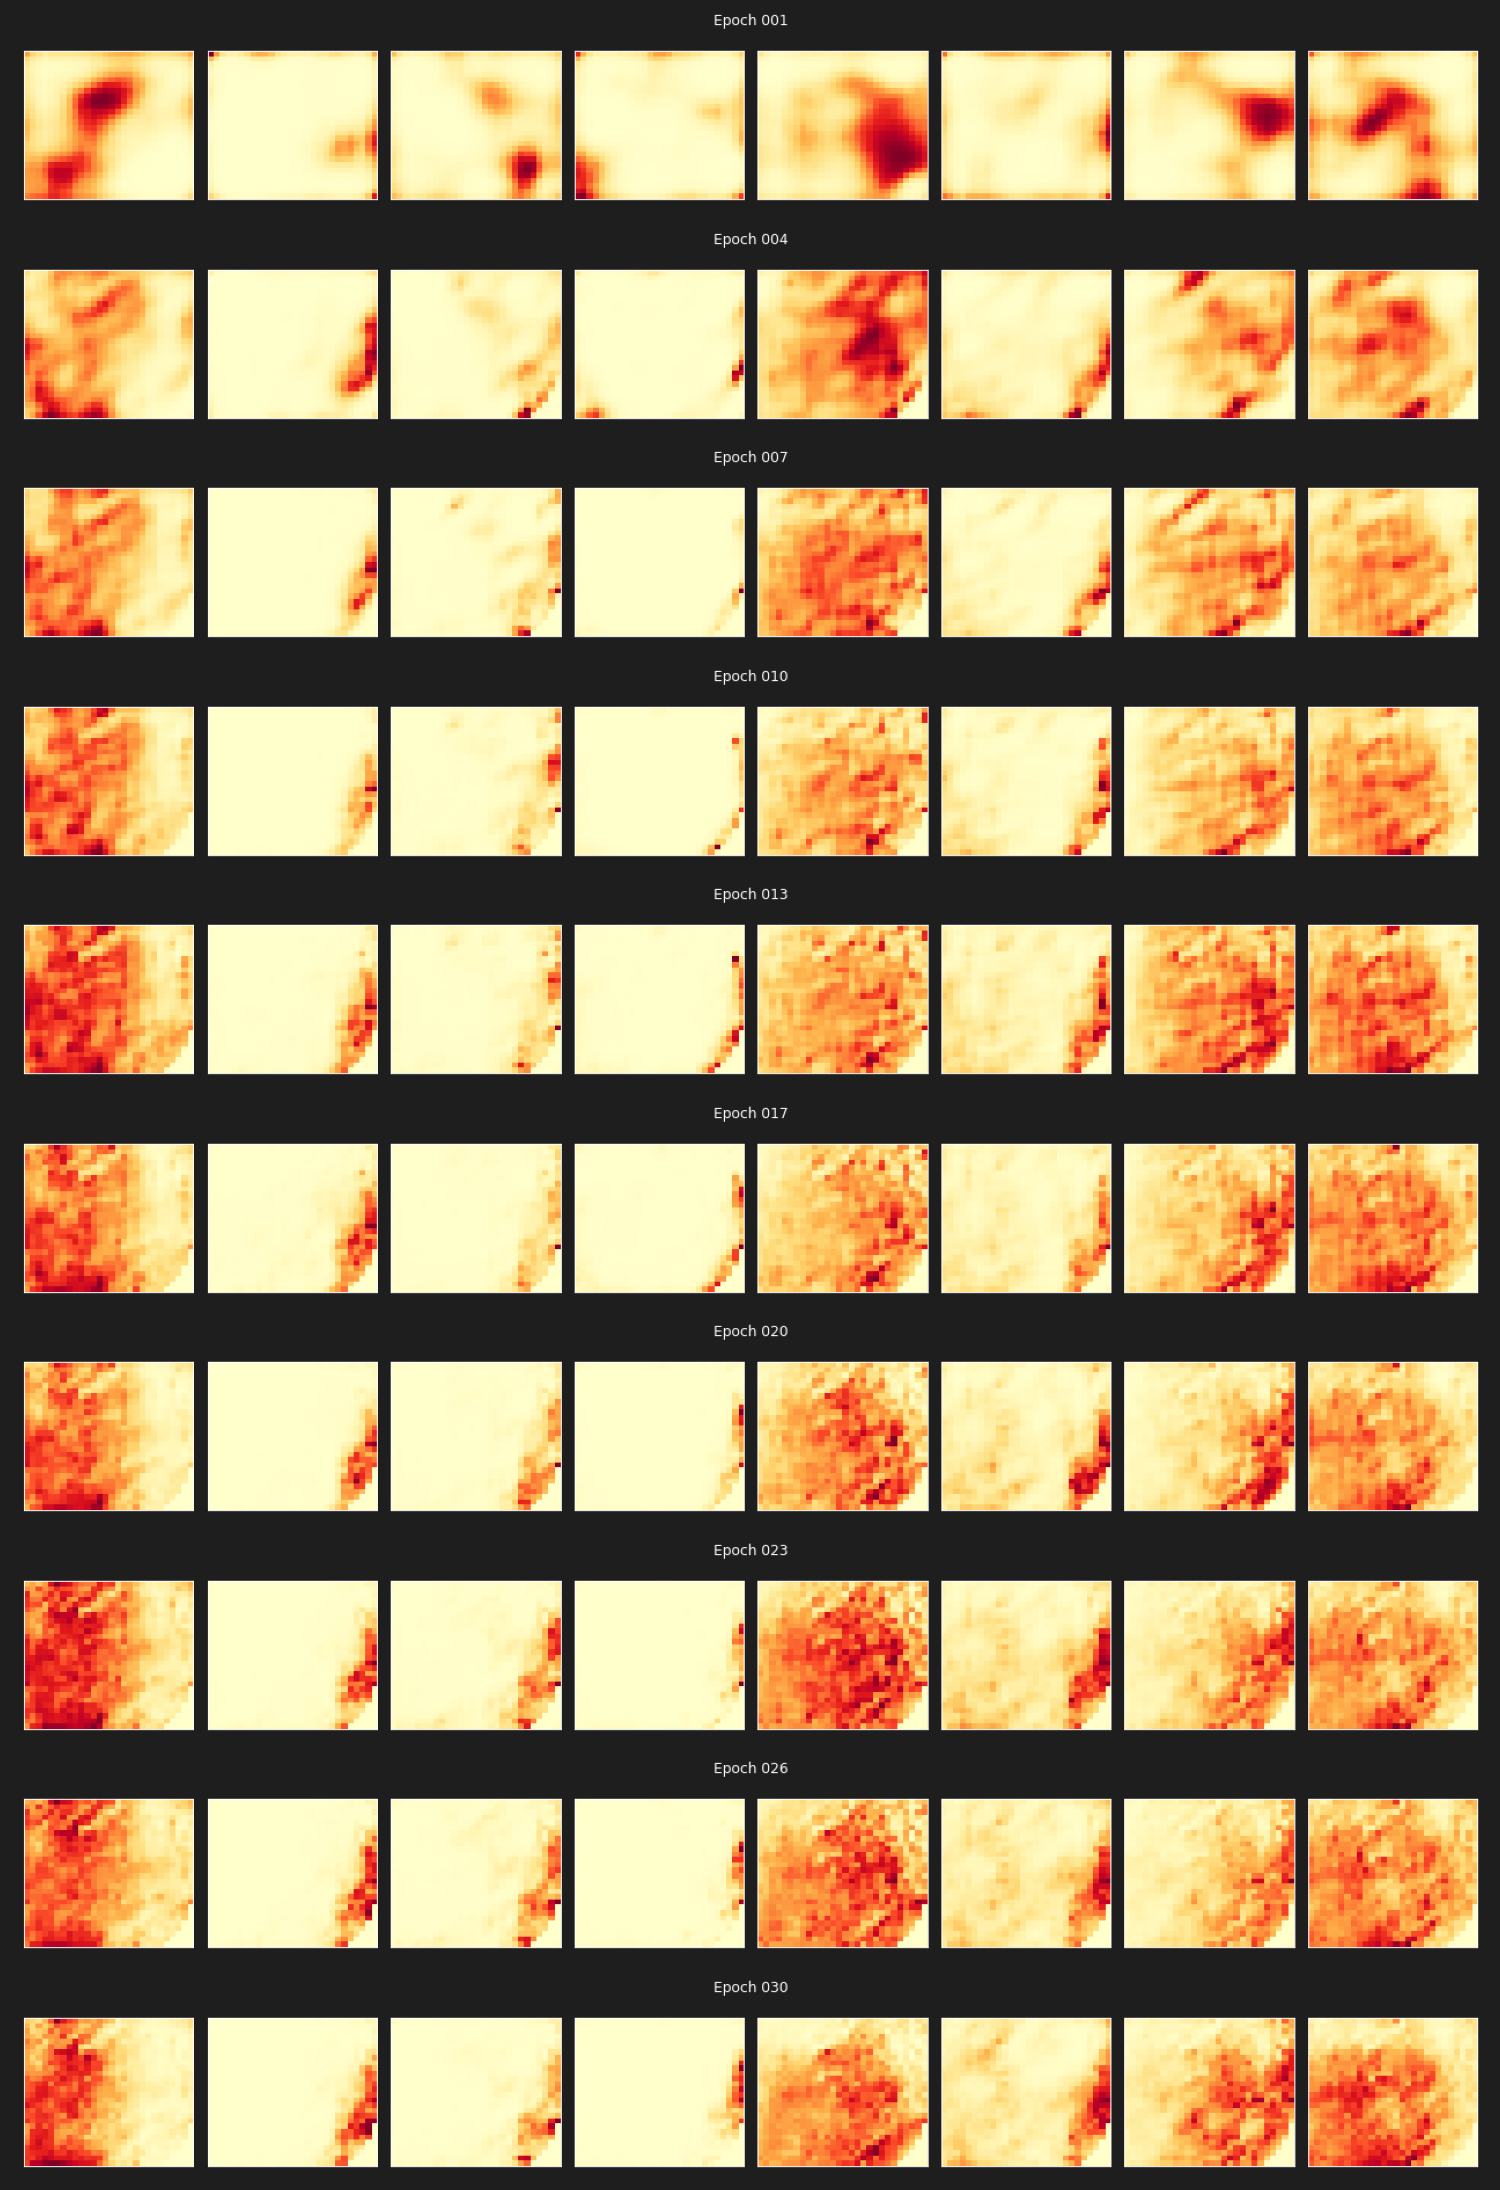

In [12]:
from matplotlib.image import imread

files = sorted([f for f in os.listdir("./run_images_naive") if f.endswith(".png")])
n_show = min(10, len(files))
idx_show = np.linspace(0, len(files)-1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 1, figsize=(2*num_img, 2.2*n_show), facecolor="#1e1e1e")
if n_show == 1: axes = [axes]
for ax, k in zip(axes, idx_show):
    img = imread(f"./run_images_naive/{files[k]}")
    ax.imshow(img); ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Comparaison : images générées vs vrais échantillons du test set

Le test set (2004-2005) n'a **jamais** été vu par le modèle. On compare visuellement :
- ligne du haut : **vrais** échantillons du test
- ligne du bas : **fausses** images générées par le générateur

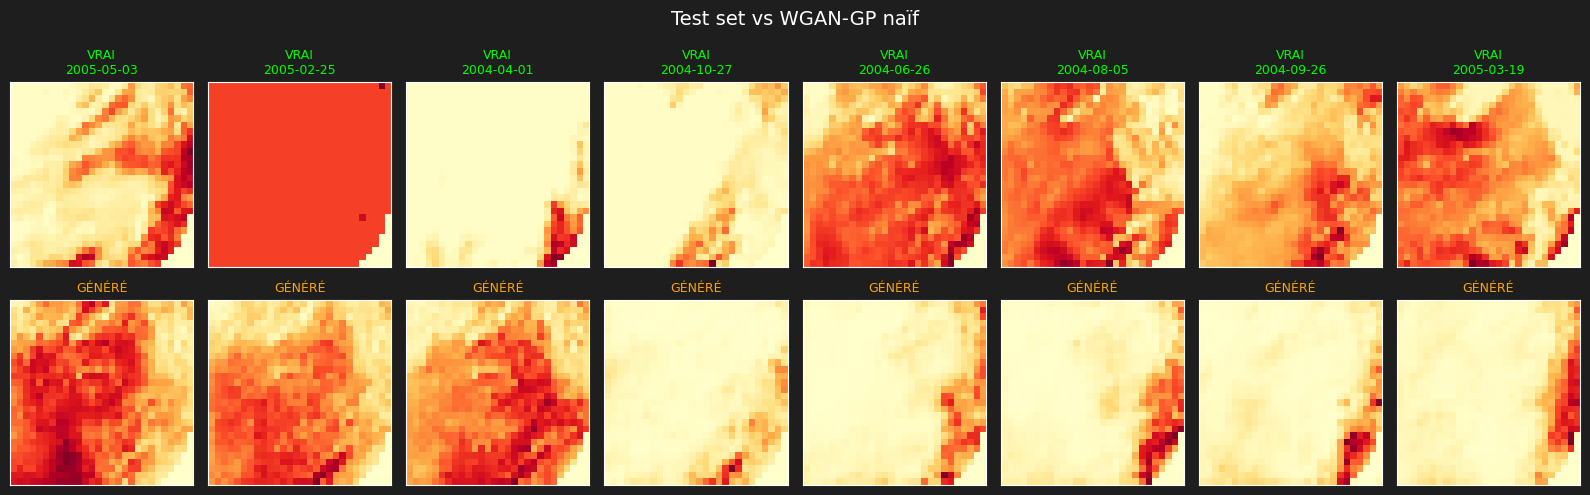

In [13]:
# ---- Génère num_img images ---------------------------------------------
np.random.seed(123)
z = tf.random.normal((num_img, latent_dim))
fake_images = gan.generator(z, training=False).numpy()

# ---- Sélectionne num_img vrais échantillons du test --------------------
idx_test = np.random.choice(len(x_test), size=num_img, replace=False)
real_test = x_test[idx_test]

# ---- Affichage ---------------------------------------------------------
BG = "#1e1e1e"
fig, axes = plt.subplots(2, num_img, figsize=(2*num_img, 5), facecolor=BG)

for i in range(num_img):
    # ligne 0 : vrais (test)
    ax = axes[0, i]
    ax.set_facecolor(BG)
    img = real_test[i, ..., 0] * x_max
    ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    date_str = test_dates.iloc[idx_test[i]].strftime("%Y-%m-%d") if hasattr(test_dates, 'iloc') \
               else pd.Timestamp(test_dates[idx_test[i]]).strftime("%Y-%m-%d")
    ax.set_title(f"VRAI\n{date_str}", color="lime", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

    # ligne 1 : générés
    ax = axes[1, i]
    ax.set_facecolor(BG)
    img = fake_images[i, ..., 0] * x_max
    ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    ax.set_title("GÉNÉRÉ", color="orange", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

plt.suptitle("Test set vs WGAN-GP naïf", color="white", fontsize=14)
plt.tight_layout()
plt.show()

### 6.1 Statistiques moyennes : générées vs test
On compare distribution moyenne et écart-type pixel-à-pixel pour repérer un éventuel **mode collapse** (un GAN qui sortirait toujours la même image aurait un écart-type quasi-nul).

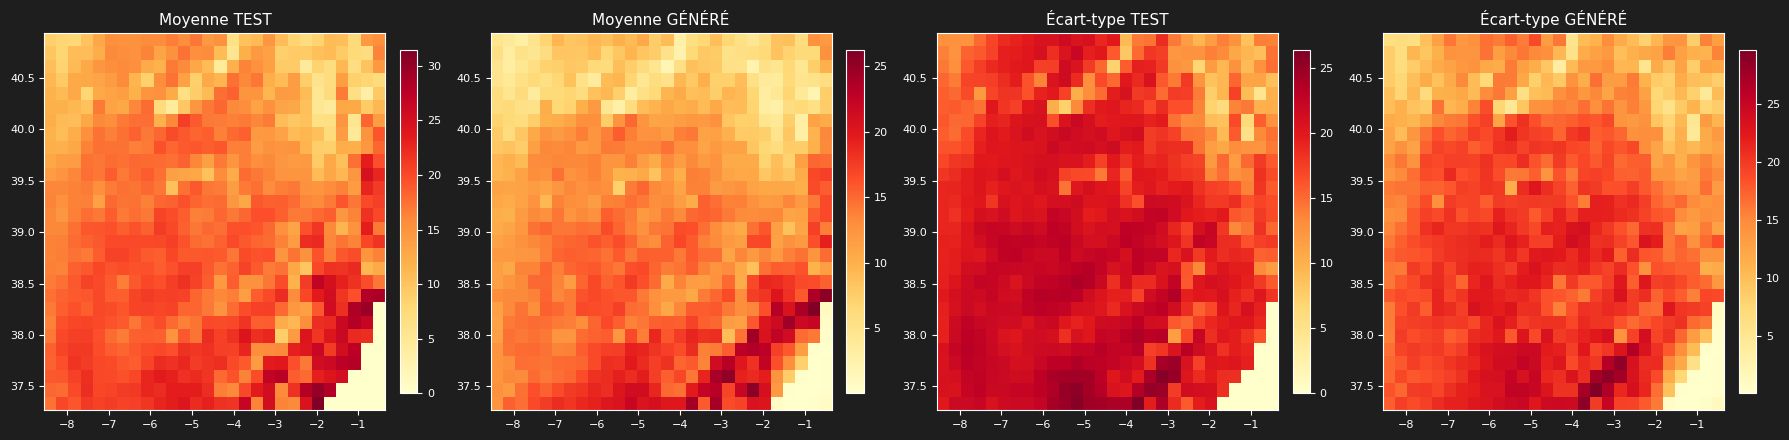

Moyenne pixel — test    : 16.522
Moyenne pixel — généré  : 12.218
Écart-type pixel — test    : 18.518
Écart-type pixel — généré  : 16.867


In [14]:
# Génère beaucoup d'images pour stats fiables
n_gen = max(500, len(x_test))
z_big = tf.random.normal((n_gen, latent_dim))
big_fake = gan.generator(z_big, training=False).numpy()  # (n_gen, 28, 28, 1)

mean_real = x_test.mean(axis=0)[..., 0] * x_max
mean_fake = big_fake.mean(axis=0)[..., 0] * x_max
std_real  = x_test.std (axis=0)[..., 0] * x_max
std_fake  = big_fake.std (axis=0)[..., 0] * x_max

BG = "#1e1e1e"
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), facecolor=BG)
titles = ["Moyenne TEST", "Moyenne GÉNÉRÉ", "Écart-type TEST", "Écart-type GÉNÉRÉ"]
images_ = [mean_real, mean_fake, std_real, std_fake]

for ax, title, img in zip(axes, titles, images_):
    ax.set_facecolor(BG)
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    ax.set_title(title, color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=8)
    for s in ax.spines.values(): s.set_color("white")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.tight_layout()
plt.show()

# Métriques scalaires
print(f"Moyenne pixel — test    : {mean_real.mean():.3f}")
print(f"Moyenne pixel — généré  : {mean_fake.mean():.3f}")
print(f"Écart-type pixel — test    : {std_real.mean():.3f}")
print(f"Écart-type pixel — généré  : {std_fake.mean():.3f}")

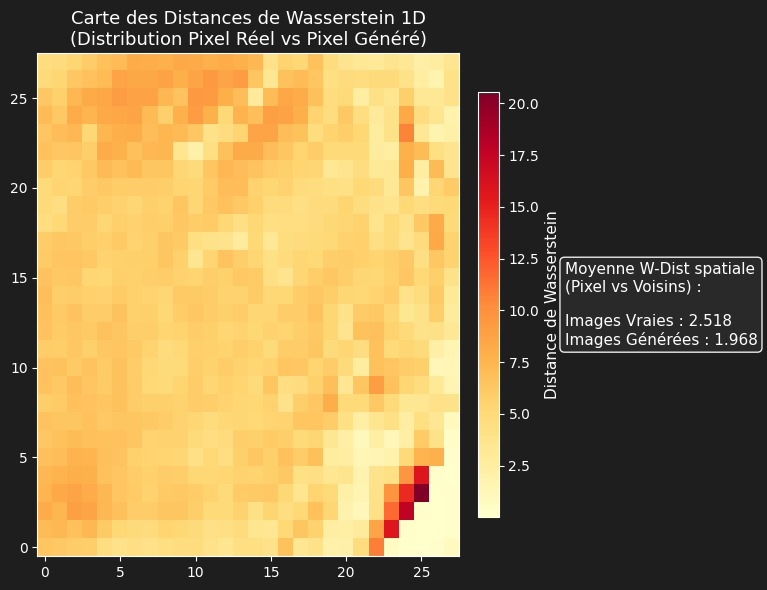

Distance Wasserstein globale moyenne sur la carte : 5.515


In [ ]:

from scipy.stats import wasserstein_distance

# --- 1. Génération des données ---
n_gen = max(500, len(x_test))
z_big = tf.random.normal((n_gen, latent_dim))
big_fake = gan.generator(z_big, training=False).numpy()  # (n_gen, 28, 28, 1)

# Retour à l'échelle physique
real_data = x_test[..., 0] * x_max
fake_data = big_fake[..., 0] * x_max

# --- 2. Calcul de la carte des Distances de Wasserstein (Vrai vs Faux) ---

wd_map = np.zeros((28, 28))
for i in range(28):
    for j in range(28):
        wd_map[i, j] = wasserstein_distance(real_data[:, i, j], fake_data[:, i, j])

# --- 3. Calcul de la W-Distance spatiale (Pixel vs ses voisins) ---
def compute_spatial_w_dist(data):
    """
    Calcule la distance de Wasserstein moyenne entre un pixel et ses 8 voisins (fenêtre 3x3).
    """
    h, w = data.shape[1], data.shape[2]
    total_dist = 0.0
    count = 0
    
    for i in range(h):
        for j in range(w):
            pixel_dist = data[:, i, j]
            # Parcours des voisins (max 8 voisins par pixel)
            for ni in range(max(0, i - 1), min(h, i + 2)):
                for nj in range(max(0, j - 1), min(w, j + 2)):
                    if ni == i and nj == j:
                        continue # On ignore le pixel lui-même
                    neighbor_dist = data[:, ni, nj]
                    total_dist += wasserstein_distance(pixel_dist, neighbor_dist)
                    count += 1
                    
    return total_dist / count if count > 0 else 0

spatial_wd_real = compute_spatial_w_dist(real_data)
spatial_wd_fake = compute_spatial_w_dist(fake_data)

# --- 4. Affichage de la carte ---
BG = "#1e1e1e"
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

# Plot de la carte 
im = ax.imshow(wd_map, cmap="YlOrRd", origin="lower", aspect="auto")
ax.set_title("Carte des Distances de Wasserstein 1D\n(Distribution Pixel Réel vs Pixel Généré)", color="white", fontsize=13)
ax.tick_params(colors="white", labelsize=10)
for s in ax.spines.values(): 
    s.set_color("white")

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor("white")
cbar.set_label("Distance de Wasserstein", color="white", fontsize=11)

# --- 5. Ajout de la légende avec les distances spatiales ---
legend_text = (
    "Moyenne W-Dist spatiale\n(Pixel vs Voisins) :\n\n"
    f"Images Vraies : {spatial_wd_real:.3f}\n"
    f"Images Générées : {spatial_wd_fake:.3f}"
)

# Place le texte dans une boîte stylisée à côté de l'image
props = dict(boxstyle='round', facecolor='#2b2b2b', alpha=0.9, edgecolor='white')
ax.text(1.25, 0.5, legend_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', color='white', bbox=props)

plt.tight_layout()
plt.show()

# Print scalaire classique en plus
print(f"Distance Wasserstein globale moyenne sur la carte : {wd_map.mean():.3f}")

---
## 7. Fine-tuning : recherche d'hyperparamètres avec Keras Tuner

On garde l'**ossature** du WGAN-GP naïf, mais on laisse le tuner choisir :

- `latent_dim`         ∈ {32, 64, 128}
- `n_critic`           ∈ {2, 3, 5}
- `lambda_gp`          ∈ {5, 10, 20}
- `learning_rate`      ∈ [1e-4, 5e-4] (log)
- `disc_filters_1`     ∈ {16, 32, 64}
- `gen_filters_base`   ∈ {32, 64, 128}
- `dropout_disc`       ∈ [0.1, 0.4]

**Particularité GAN :** il n'y a pas de "val_accuracy" naturelle. On utilise comme objectif :
$$\text{score} = -\,|\text{val\_w\_loss à la dernière epoch}|$$

L'idée : `val_w_loss` proche de 0 = critic incapable de distinguer (= générateur convaincant). On veut donc **minimiser** sa valeur absolue. Un `val_w_loss` très négatif = critic gagne facilement = générateur faible. Le tuner cherchera donc à **maximiser** cet objectif.


In [36]:
import keras_tuner as kt

# ---- Hypermodel ----
def build_wgan_gp(hp):
    # ---- HP latent / training ----
    ld = hp.Choice("latent_dim",   [8,16, 32, 64])
    nc = hp.Choice("n_critic",     [2, 3, 5])
    lg = hp.Choice("lambda_gp",    [5.0, 10.0, 20.0])
    lr = hp.Float ("learning_rate", 1e-4, 5e-4, sampling="log")

    # ---- HP architecture critic ----
    f1 = hp.Choice("disc_filters_1", [8, 16, 32])
    dd = hp.Float ("dropout_disc",   0.1, 0.4, step=0.1)

    # ---- HP architecture generator ----
    fg = hp.Choice("gen_filters_base", [8, 16, 32])

    # --- build critic ---
    inp_d = keras.Input(shape=(28, 28, 1))
    x = layers.Conv2D(f1,    4, strides=2, padding="same")(inp_d)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv2D(f1*2,  4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(dd)(x)
    out_d = layers.Dense(1)(x)
    disc  = keras.Model(inp_d, out_d, name="critic")

    # --- build generator ---
    inp_g = keras.Input(shape=(ld,))
    x = layers.Dense(7*7*fg)(inp_g)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Reshape((7, 7, fg))(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(fg,    3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.UpSampling2D()(x)
    x = layers.Conv2D(fg//2, 3, padding="same")(x)
    x = layers.LeakyReLU(0.2)(x)
    out_g = layers.Conv2D(1, 5, padding="same", activation="sigmoid")(x)
    gen   = keras.Model(inp_g, out_g, name="generator")

    # --- WGAN-GP ---
    model = WGANGP(discriminator=disc, generator=gen,
                   latent_dim=ld, n_critic=nc, lambda_gp=lg)
    model.compile(
        d_optimizer=keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.9),
        g_optimizer=keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.9),
    )
    return model

### 7.1 Tuner custom avec objectif `|val_w_loss|` minimisé

Keras Tuner attend une métrique scalaire. On définit donc une sous-classe qui calcule, à la fin de chaque trial, `val_score = -abs(val_w_loss_final)`. Le tuner **maximise** cet objectif (donc minimise `|val_w_loss|`).

In [37]:
class GANBayesianTuner(kt.BayesianOptimization):
    # Tuner qui transforme la dernière val_w_loss d'un trial en objectif scalaire.

    def run_trial(self, trial, *args, **kwargs):
        hp     = trial.hyperparameters
        model  = self.hypermodel.build(hp)
        history = model.fit(*args, **kwargs)

        val_w = history.history.get("val_w_loss", [None])[-1]
        if val_w is None:
            score = -1e9
        else:
            score = -abs(float(val_w))

        return {"val_score": score}


tuner = GANBayesianTuner(
    hypermodel    = build_wgan_gp,
    objective     = kt.Objective("val_score", direction="max"),
    max_trials    = 30,        
    num_initial_points = 8,
    directory     = "kt_wgangp",
    project_name  = "fwi_wgangp_bayes",
    overwrite     = True,
)

tuner.search_space_summary()

Search space summary
Default search space size: 7
latent_dim (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32, 64], 'ordered': True}
n_critic (Choice)
{'default': 2, 'conditions': [], 'values': [2, 3, 5], 'ordered': True}
lambda_gp (Choice)
{'default': 5.0, 'conditions': [], 'values': [5.0, 10.0, 20.0], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.0005, 'step': None, 'sampling': 'log'}
disc_filters_1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
dropout_disc (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
gen_filters_base (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}


### 7.2 Lancement de la recherche

⚠️ Pour une recherche tractable, on utilise **moins d'epochs** (10) qu'en entraînement final.

### 7.3 Meilleurs hyperparamètres trouvés

In [38]:
SEARCH_EPOCHS = 15

tuner.search(
    x_train,
    validation_data = x_valid,
    epochs          = SEARCH_EPOCHS,
    batch_size      = batch_size,
    verbose         = 1,
)

Trial 30 Complete [00h 02m 56s]
val_score: -0.23768499493598938

Best val_score So Far: -0.00874689593911171
Total elapsed time: 01h 35m 22s


In [39]:
tuner.results_summary(num_trials=5)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\n=== Meilleurs hyperparamètres ===")
for k, v in best_hp.values.items():
    print(f"  {k:20s} = {v}")

Results summary
Results in kt_wgangp/fwi_wgangp_bayes
Showing 5 best trials
Objective(name="val_score", direction="max")

Trial 06 summary
Hyperparameters:
latent_dim: 64
n_critic: 2
lambda_gp: 10.0
learning_rate: 0.0003072940706808044
disc_filters_1: 16
dropout_disc: 0.2
gen_filters_base: 32
Score: -0.00874689593911171

Trial 09 summary
Hyperparameters:
latent_dim: 64
n_critic: 2
lambda_gp: 10.0
learning_rate: 0.00034398064751976884
disc_filters_1: 8
dropout_disc: 0.2
gen_filters_base: 32
Score: -0.025326980277895927

Trial 22 summary
Hyperparameters:
latent_dim: 16
n_critic: 2
lambda_gp: 20.0
learning_rate: 0.0001403877781697142
disc_filters_1: 8
dropout_disc: 0.30000000000000004
gen_filters_base: 32
Score: -0.03597961366176605

Trial 18 summary
Hyperparameters:
latent_dim: 8
n_critic: 5
lambda_gp: 20.0
learning_rate: 0.000275263205547408
disc_filters_1: 8
dropout_disc: 0.30000000000000004
gen_filters_base: 32
Score: -0.04554976522922516

Trial 25 summary
Hyperparameters:
latent_dim:

### 7.4 Ré-entraînement final avec les meilleurs HP
On entraîne plus longtemps (30 epochs) le modèle gagnant, en sauvant des images au fil des epochs.

In [40]:
best_gan = tuner.hypermodel.build(best_hp)

img_cb_best = FwiImagesCallback(
    num_img    = num_img,
    latent_dim = best_hp.values["latent_dim"],
    run_dir    = "./run_images_best",
    x_max      = x_max,
    extent     = extent,
)

history_best = best_gan.fit(
    x_train,
    validation_data = x_valid,
    epochs          = 30,
    batch_size      = batch_size,
    callbacks       = [img_cb_best],
    verbose         = 1,
)

Epoch 1/30


E0000 00:00:1777171875.488439  659012 meta_optimizer.cc:967] remapper failed: INVALID_ARGUMENT: Mutation::Apply error: fanout 'StatefulPartitionedCall/gradient_tape/critic_1/leaky_re_lu_335_1/LeakyRelu/LeakyReluGrad' exist for missing node 'StatefulPartitionedCall/critic_1/conv2d_335_1/BiasAdd'.


177/177 ━━━━━━━━━━━━━━━━━━━━ 15s 57ms/step - d_loss: -0.1860 - g_loss: 0.3511 - w_loss: -0.7528 - val_d_loss: -0.5432 - val_g_loss: -0.5396 - val_w_loss: -0.5432
Epoch 2/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 46ms/step - d_loss: -0.7239 - g_loss: -0.9581 - w_loss: -0.7634 - val_d_loss: -0.4536 - val_g_loss: -1.4579 - val_w_loss: -0.4536
Epoch 3/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - d_loss: -0.4811 - g_loss: -1.5039 - w_loss: -0.5061 - val_d_loss: -0.4065 - val_g_loss: -1.4285 - val_w_loss: -0.4065
Epoch 4/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - d_loss: -0.3649 - g_loss: -1.0600 - w_loss: -0.3871 - val_d_loss: -0.5033 - val_g_loss: -1.6918 - val_w_loss: -0.5033
Epoch 5/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 49ms/step - d_loss: -0.3275 - g_loss: -0.4856 - w_loss: -0.3582 - val_d_loss: -0.2207 - val_g_loss: -1.7885 - val_w_loss: -0.2207
Epoch 6/30
177/177 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - d_loss: -0.2535 - g_loss: -0.2774 - w_loss: -0.2792 - val_d_loss: -0.1589 - val_g_loss: 0.1

### 7.5 Loss train / valid du modèle optimisé

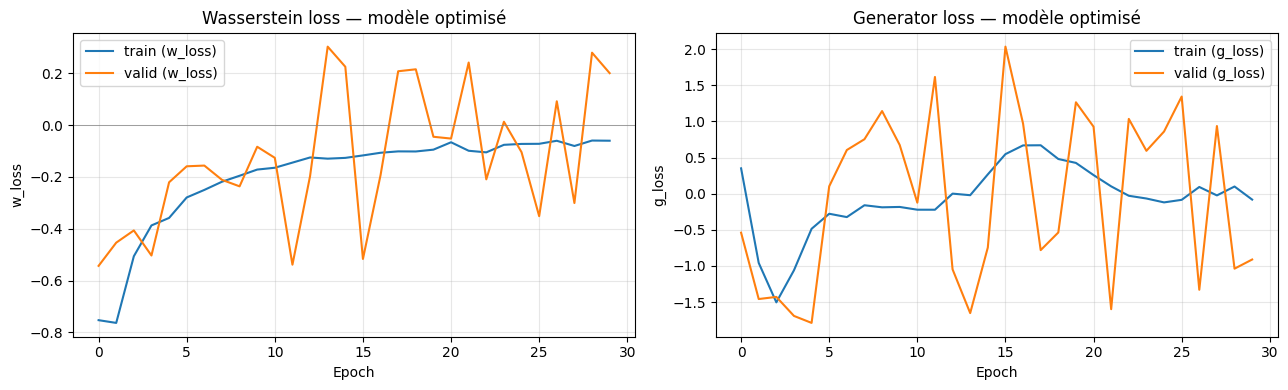

In [41]:
hb = history_best.history

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hb["w_loss"],     label="train (w_loss)")
if "val_w_loss" in hb:
    axes[0].plot(hb["val_w_loss"], label="valid (w_loss)")
axes[0].set_title("Wasserstein loss — modèle optimisé")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("w_loss")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].axhline(0, color="grey", lw=0.5)

axes[1].plot(hb["g_loss"],     label="train (g_loss)")
if "val_g_loss" in hb:
    axes[1].plot(hb["val_g_loss"], label="valid (g_loss)")
axes[1].set_title("Generator loss — modèle optimisé")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("g_loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

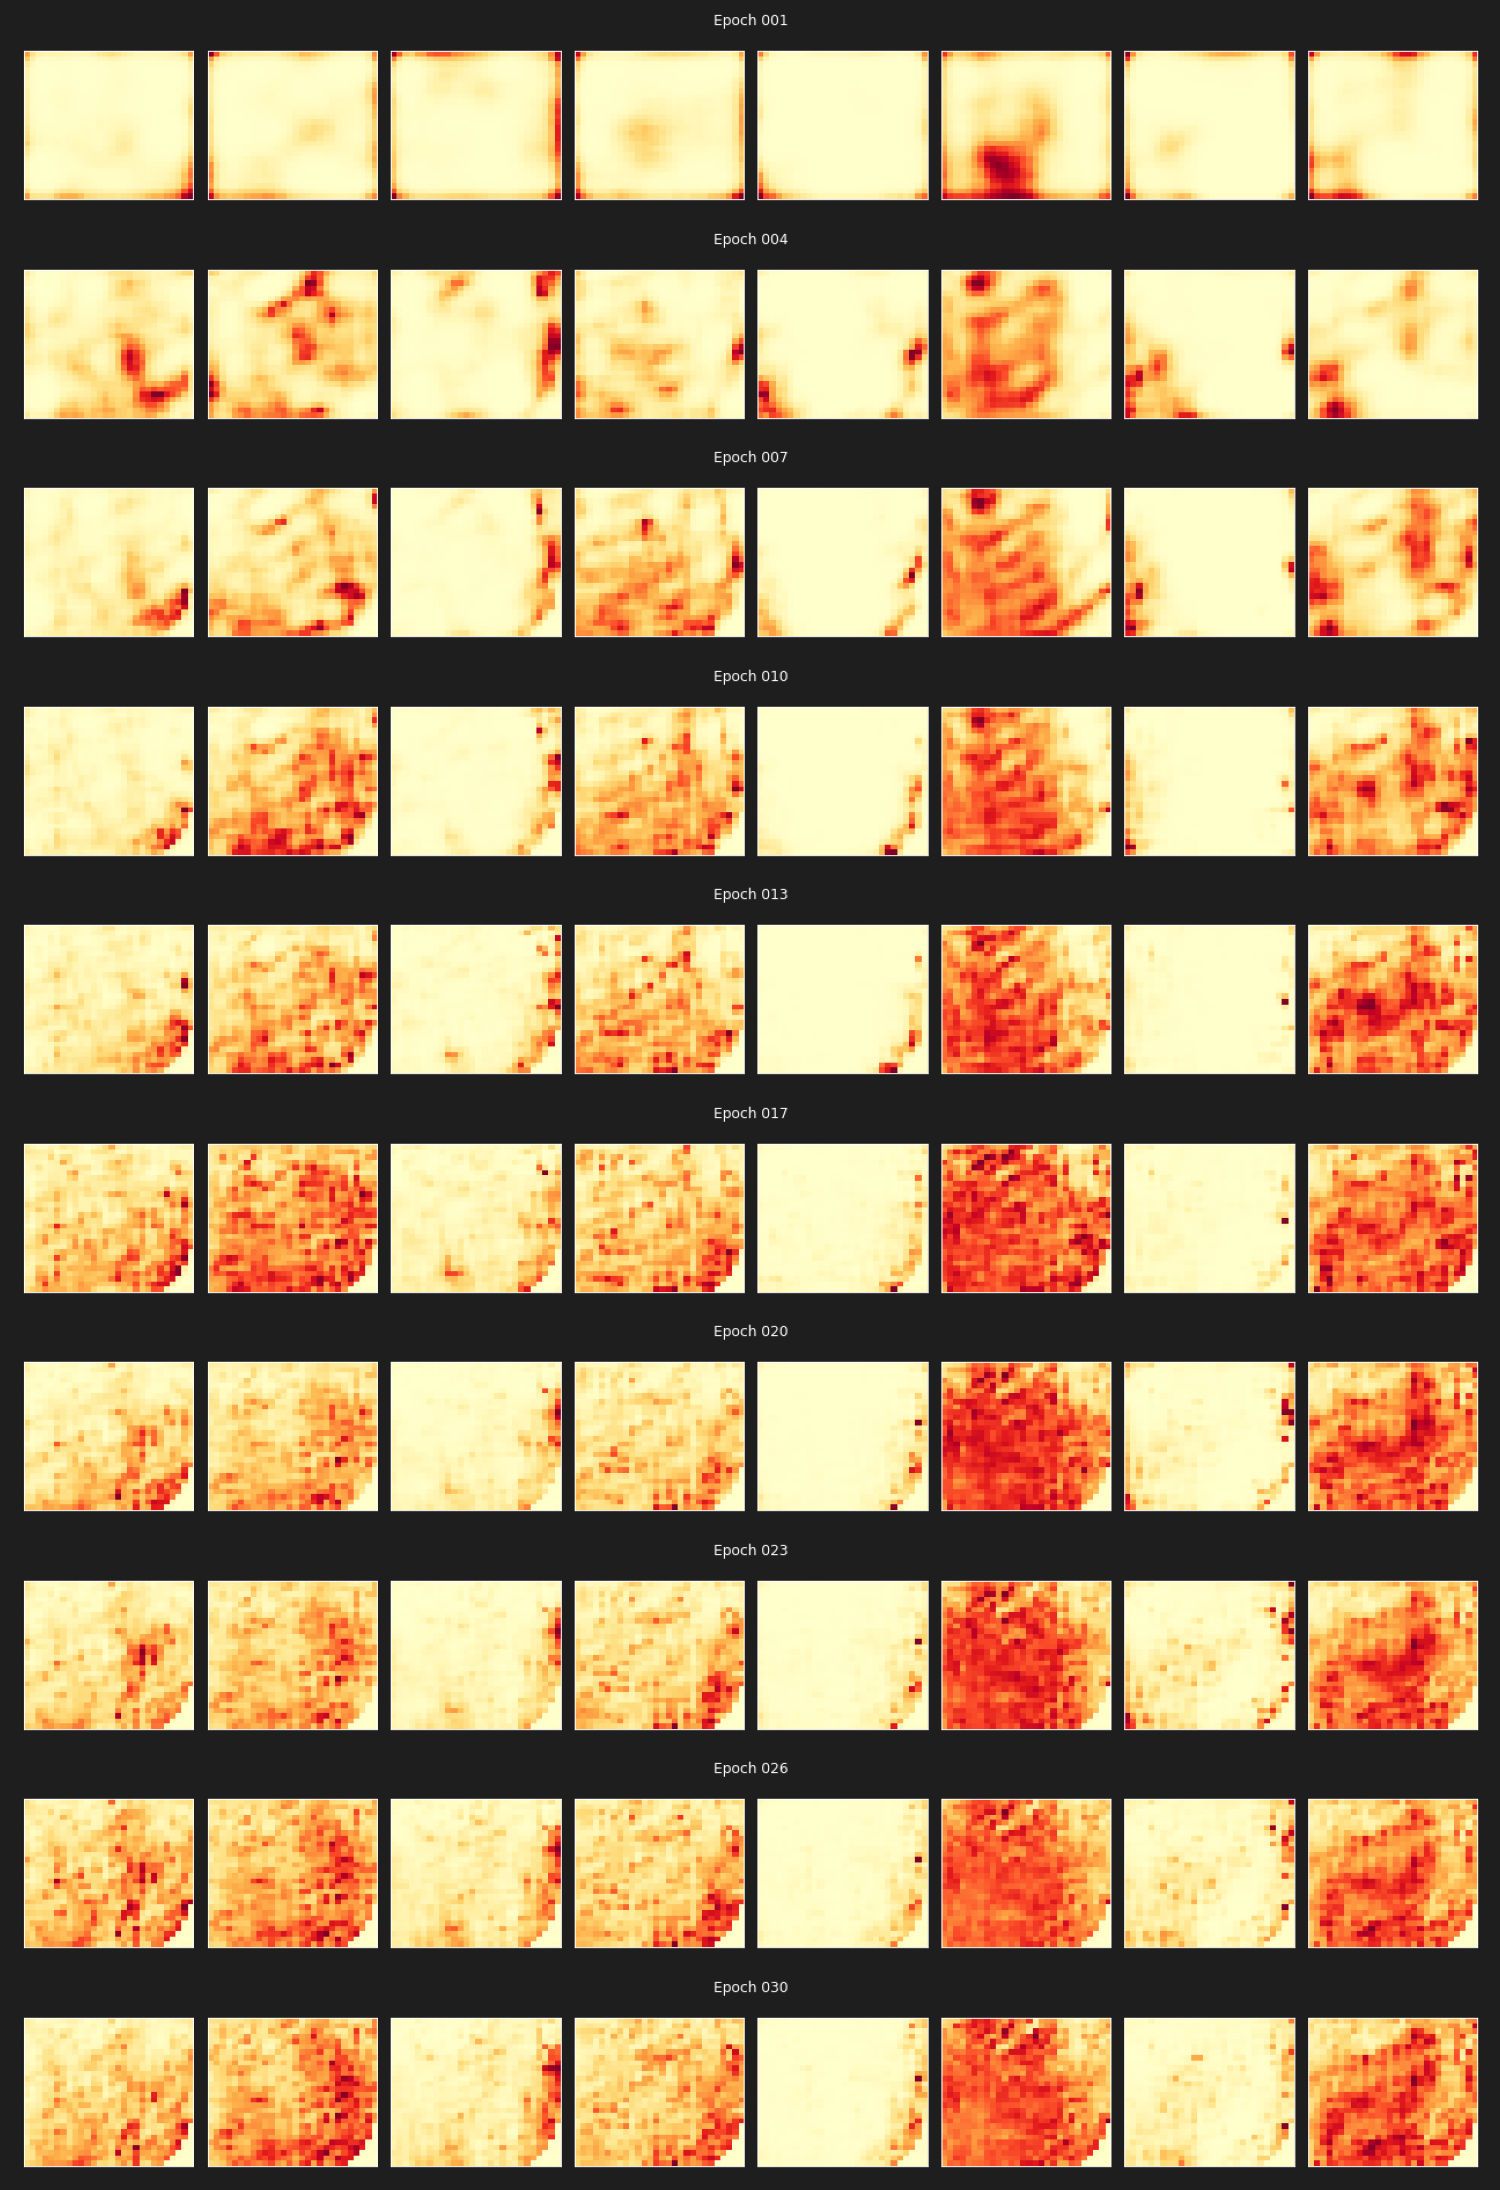

In [42]:
from matplotlib.image import imread

files = sorted([f for f in os.listdir("./run_images_best") if f.endswith(".png")])
n_show = min(10, len(files))
idx_show = np.linspace(0, len(files)-1, n_show, dtype=int)

fig, axes = plt.subplots(n_show, 1, figsize=(2*num_img, 2.2*n_show), facecolor="#1e1e1e")
if n_show == 1: axes = [axes]
for ax, k in zip(axes, idx_show):
    img = imread(f"./run_images_best/{files[k]}")
    ax.imshow(img); ax.axis("off")
plt.tight_layout()
plt.show()

### 7.6 Comparaison finale : test vs WGAN-GP optimisé

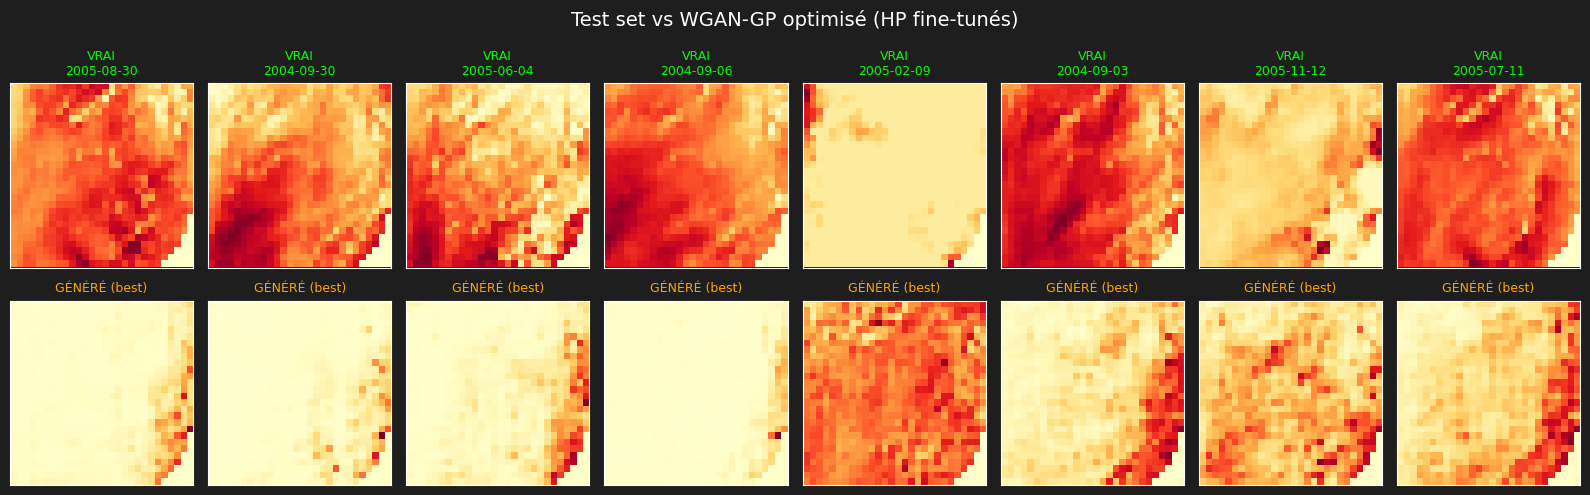

In [43]:
ld_best = best_hp.values["latent_dim"]
np.random.seed(456)
z = tf.random.normal((num_img, ld_best))
fake_best = best_gan.generator(z, training=False).numpy()

idx_test = np.random.choice(len(x_test), size=num_img, replace=False)
real_test = x_test[idx_test]

BG = "#1e1e1e"
fig, axes = plt.subplots(2, num_img, figsize=(2*num_img, 5), facecolor=BG)

for i in range(num_img):
    ax = axes[0, i]
    ax.set_facecolor(BG)
    img = real_test[i, ..., 0] * x_max
    ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    date_str = test_dates.iloc[idx_test[i]].strftime("%Y-%m-%d") if hasattr(test_dates, 'iloc') \
               else pd.Timestamp(test_dates[idx_test[i]]).strftime("%Y-%m-%d")
    ax.set_title(f"VRAI\n{date_str}", color="lime", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

    ax = axes[1, i]
    ax.set_facecolor(BG)
    img = fake_best[i, ..., 0] * x_max
    ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    ax.set_title("GÉNÉRÉ (best)", color="orange", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("white")

plt.suptitle("Test set vs WGAN-GP optimisé (HP fine-tunés)", color="white", fontsize=14)
plt.tight_layout()
plt.show()

### 7.7 Naïf vs optimisé : courbes côte à côte

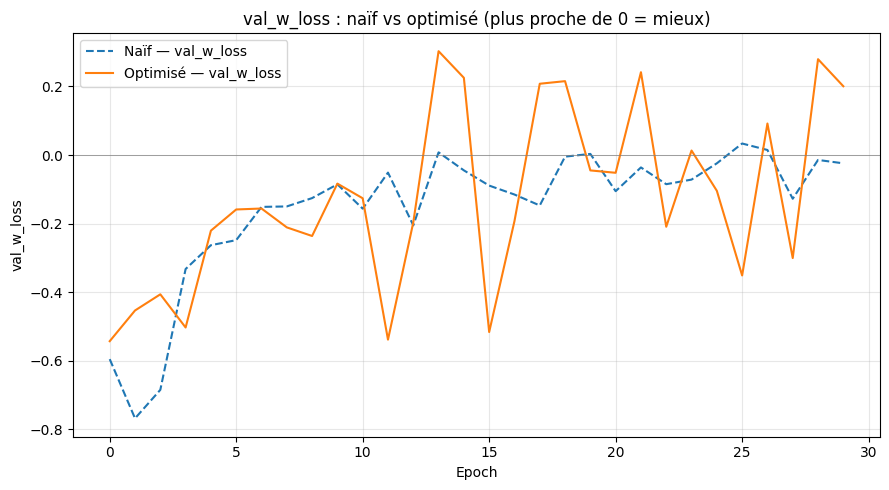

Naïf      : val_w_loss final = -0.0243
Optimisé  : val_w_loss final = 0.2006


In [44]:
fig, ax = plt.subplots(figsize=(9, 5))

if "val_w_loss" in h:
    ax.plot(h["val_w_loss"],  label="Naïf — val_w_loss",  linestyle="--")
if "val_w_loss" in hb:
    ax.plot(hb["val_w_loss"], label="Optimisé — val_w_loss")

ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("val_w_loss")
ax.set_title("val_w_loss : naïf vs optimisé (plus proche de 0 = mieux)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Résumé chiffré
if 'val_w_loss' in h:
    print(f"Naïf      : val_w_loss final = {h['val_w_loss'][-1]:.4f}")
if 'val_w_loss' in hb:
    print(f"Optimisé  : val_w_loss final = {hb['val_w_loss'][-1]:.4f}")

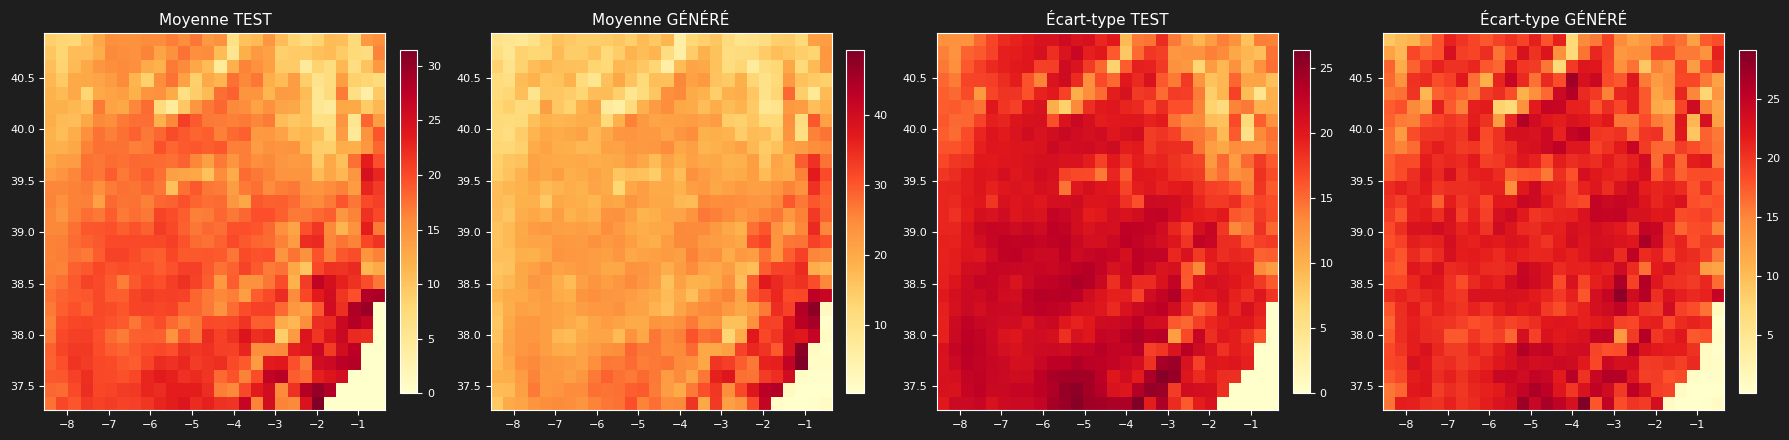

Moyenne pixel — test    : 16.522
Moyenne pixel — généré  : 20.759
Écart-type pixel — test    : 18.518
Écart-type pixel — généré  : 19.648


In [ ]:
n_gen = max(500, len(x_test))
z_big = tf.random.normal((n_gen, latent_dim))
big_fake = best_gan.generator(z_big, training=False).numpy()  # (n_gen, 28, 28, 1)

mean_real = x_test.mean(axis=0)[..., 0] * x_max
mean_fake = big_fake.mean(axis=0)[..., 0] * x_max
std_real  = x_test.std (axis=0)[..., 0] * x_max
std_fake  = big_fake.std (axis=0)[..., 0] * x_max

BG = "#1e1e1e"
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), facecolor=BG)
titles = ["Moyenne TEST", "Moyenne GÉNÉRÉ", "Écart-type TEST", "Écart-type GÉNÉRÉ"]
images_ = [mean_real, mean_fake, std_real, std_fake]

for ax, title, img in zip(axes, titles, images_):
    ax.set_facecolor(BG)
    im = ax.imshow(img, cmap="YlOrRd", origin="lower", extent=extent, aspect="auto")
    ax.set_title(title, color="white", fontsize=11)
    ax.tick_params(colors="white", labelsize=8)
    for s in ax.spines.values(): s.set_color("white")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(colors="white", labelsize=8)
    cbar.outline.set_edgecolor("white")

plt.tight_layout()
plt.show()

# Métriques scalaires
print(f"Moyenne pixel — test    : {mean_real.mean():.3f}")
print(f"Moyenne pixel — généré  : {mean_fake.mean():.3f}")
print(f"Écart-type pixel — test    : {std_real.mean():.3f}")
print(f"Écart-type pixel — généré  : {std_fake.mean():.3f}")

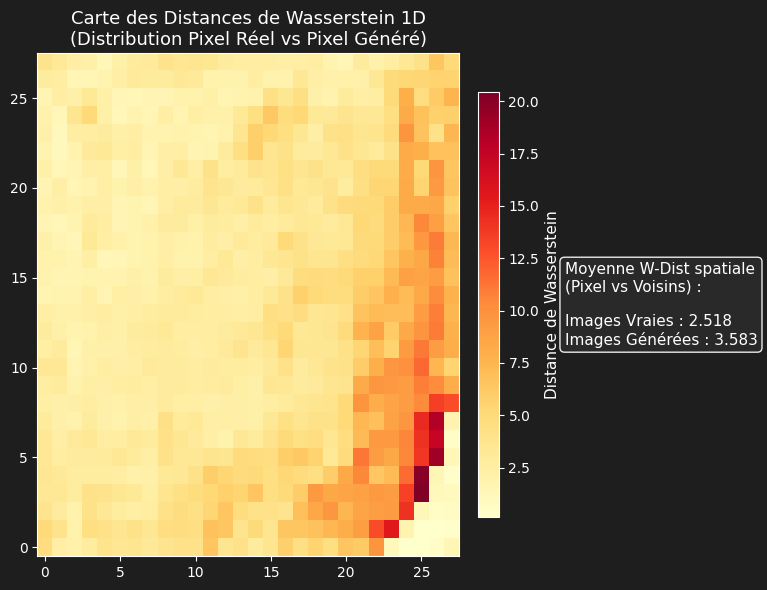

Distance Wasserstein globale moyenne sur la carte : 4.156


In [ ]:

from scipy.stats import wasserstein_distance

# --- 1. Génération des données ---
n_gen = max(500, len(x_test))
z_big = tf.random.normal((n_gen, latent_dim))
big_fake = best_gan.generator(z_big, training=False).numpy()  # (n_gen, 28, 28, 1)

# Retour à l'échelle physique
real_data = x_test[..., 0] * x_max
fake_data = big_fake[..., 0] * x_max

# --- 2. Calcul de la carte des Distances de Wasserstein (Vrai vs Faux) ---

wd_map = np.zeros((28, 28))
for i in range(28):
    for j in range(28):
        wd_map[i, j] = wasserstein_distance(real_data[:, i, j], fake_data[:, i, j])

# --- 3. Calcul de la W-Distance spatiale (Pixel vs ses voisins) ---
def compute_spatial_w_dist(data):
    """
    Calcule la distance de Wasserstein moyenne entre un pixel et ses 8 voisins (fenêtre 3x3).
    """
    h, w = data.shape[1], data.shape[2]
    total_dist = 0.0
    count = 0
    
    for i in range(h):
        for j in range(w):
            pixel_dist = data[:, i, j]
            # Parcours des voisins (max 8 voisins par pixel)
            for ni in range(max(0, i - 1), min(h, i + 2)):
                for nj in range(max(0, j - 1), min(w, j + 2)):
                    if ni == i and nj == j:
                        continue # On ignore le pixel lui-même
                    neighbor_dist = data[:, ni, nj]
                    total_dist += wasserstein_distance(pixel_dist, neighbor_dist)
                    count += 1
                    
    return total_dist / count if count > 0 else 0

spatial_wd_real = compute_spatial_w_dist(real_data)
spatial_wd_fake = compute_spatial_w_dist(fake_data)

# --- 4. Affichage de la carte ---
BG = "#1e1e1e"
fig, ax = plt.subplots(1, 1, figsize=(8, 6), facecolor=BG)
ax.set_facecolor(BG)

# Plot de la carte 
im = ax.imshow(wd_map, cmap="YlOrRd", origin="lower", aspect="auto")
ax.set_title("Carte des Distances de Wasserstein 1D\n(Distribution Pixel Réel vs Pixel Généré)", color="white", fontsize=13)
ax.tick_params(colors="white", labelsize=10)
for s in ax.spines.values(): 
    s.set_color("white")

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(colors="white", labelsize=10)
cbar.outline.set_edgecolor("white")
cbar.set_label("Distance de Wasserstein", color="white", fontsize=11)

# --- 5. Ajout de la légende avec les distances spatiales ---
legend_text = (
    "Moyenne W-Dist spatiale\n(Pixel vs Voisins) :\n\n"
    f"Images Vraies : {spatial_wd_real:.3f}\n"
    f"Images Générées : {spatial_wd_fake:.3f}"
)

# Place le texte dans une boîte stylisée à côté de l'image
props = dict(boxstyle='round', facecolor='#2b2b2b', alpha=0.9, edgecolor='white')
ax.text(1.25, 0.5, legend_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', color='white', bbox=props)

plt.tight_layout()
plt.show()

# Print scalaire classique en plus
print(f"Distance Wasserstein globale moyenne sur la carte : {wd_map.mean():.3f}")

In [47]:
generator_path = "../fwi_generator_wgangp.h5"
best_gan.generator.save(generator_path)

print(f"Générateur sauvegardé sous : {generator_path}")

Générateur sauvegardé sous : ../fwi_generator_wgangp.h5
